Эпизод   50 | Средняя: -200.00 | Лучшая: -200.00 | Шум: 0.0100
Эпизод  100 | Средняя: -199.96 | Лучшая: -200.00 | Шум: 0.0100
Эпизод  150 | Средняя: -175.80 | Лучшая: -132.00 | Шум: 0.0999
Эпизод  200 | Средняя: -148.96 | Лучшая:  -86.00 | Шум: 0.5721
Эпизод  250 | Средняя: -119.76 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  300 | Средняя: -114.80 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  350 | Средняя: -118.58 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  400 | Средняя: -117.12 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  450 | Средняя: -112.98 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  500 | Средняя: -114.00 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  550 | Средняя: -112.34 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  600 | Средняя: -112.54 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  650 | Средняя: -113.50 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  700 | Средняя: -109.96 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  750 | Средняя: -109.90 | Лучшая:  -86.00 | Шум: 1.9800
Эпизод  800 | Средняя: -101.28 | Лучшая:  -86.00 | Шум:

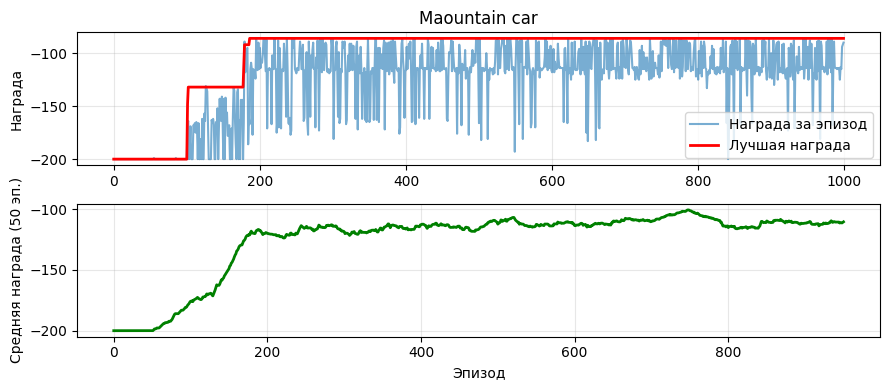

Тест 1: Награда = -167.00
Тест 2: Награда = -102.00
Тест 3: Награда = -94.00
Тест 4: Награда = -90.00
Тест 5: Награда = -106.00

Результаты тестирования:
Средняя награда: -111.80
Лучшая награда: -90.00
Худшая награда: -167.00


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

class HillClimbingAgent:
    def __init__(self, state_space, action_space):
        self.state_space = state_space
        self.action_space = action_space
        self.initial_noise = 2.0
        self.noise_scale = self.initial_noise
        self.noise_decay = 0.99
        self.min_noise = 0.01
        self.noise_increase = 1.5
        self.patience = 20
        self.no_improvement_count = 0
        self.best_reward = -float('inf')
        self.best_weights = None
        
        self.weights = self.initialize_weights()
        self.best_weights = self.weights.copy()
        
        self.state_mean = np.zeros(state_space)
        self.state_std = np.ones(state_space)
        
    def initialize_weights(self):
        limit = np.sqrt(6.0 / (self.state_space + self.action_space))
        return np.random.uniform(-limit, limit, (self.state_space, self.action_space))
    
    def normalize_state(self, state):
        return (state - self.state_mean) / (self.state_std + 1e-8)
    
    def update_normalization(self, states):
        if len(states) > 0:
            self.state_mean = np.mean(states, axis=0)
            self.state_std = np.std(states, axis=0)
    
    def get_action(self, state, exploration=False):
        state_norm = self.normalize_state(state)
        q_values = np.dot(state_norm, self.weights)
        return np.argmax(q_values)
    
    def propose_new_weights(self):
        if self.no_improvement_count > self.patience:
            noise = np.random.randn(*self.weights.shape) * (self.noise_scale * self.noise_increase)
        else:
            noise = np.random.randn(*self.weights.shape) * self.noise_scale
        
        return self.weights + noise
    
    def update(self, new_weights, new_reward):
        if new_reward >= self.best_reward:
            improvement = new_reward - self.best_reward
            self.weights = new_weights
            self.best_reward = new_reward
            self.best_weights = new_weights.copy()
            self.no_improvement_count = 0
            
            self.noise_scale = max(self.min_noise, self.noise_scale * 0.9)
            return True, improvement
        else:
            self.no_improvement_count += 1
            
            if self.no_improvement_count > self.patience:
                self.noise_scale = min(self.initial_noise, self.noise_scale * 1.1)
            
            return False, 0
    
    def decay_noise(self):
        self.noise_scale = max(self.min_noise, self.noise_scale * self.noise_decay)

def train_enhanced_hill_climbing(env, num_episodes=1000, max_steps=200):
    state_space = env.observation_space.shape[0]
    action_space = env.action_space.n
    
    agent = HillClimbingAgent(state_space, action_space)
    
    rewards_history = []
    noise_history = []
    best_rewards_history = []
    
    states_buffer = []
    
    for episode in range(num_episodes):
        state = env.reset()
        state = state[0] if isinstance(state, tuple) else state
        states_buffer.append(state)
        
        current_reward = evaluate_policy(env, agent, max_steps, exploration=False)
        
        new_weights = agent.propose_new_weights()
        temp_agent = HillClimbingAgent(state_space, action_space)
        temp_agent.weights = new_weights
        temp_agent.state_mean = agent.state_mean
        temp_agent.state_std = agent.state_std
        
        new_reward = evaluate_policy(env, temp_agent, max_steps, exploration=False)
        
        improved, improvement = agent.update(new_weights, new_reward)
        
        agent.decay_noise()
        
        if len(states_buffer) > 100:
            agent.update_normalization(np.array(states_buffer[-100:]))
        
        rewards_history.append(current_reward)
        noise_history.append(agent.noise_scale)
        best_rewards_history.append(agent.best_reward)
        
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(rewards_history[-50:])
            print(f"Эпизод {episode + 1:4d} | "
                  f"Средняя: {avg_reward:7.2f} | "
                  f"Лучшая: {agent.best_reward:7.2f} | "
                  f"Шум: {agent.noise_scale:.4f}"
                  )
    
    agent.weights = agent.best_weights
    return agent, rewards_history, best_rewards_history, noise_history

def evaluate_policy(env, agent, max_steps=200, exploration=False):
    state = env.reset()
    state = state[0] if isinstance(state, tuple) else state
    
    total_reward = 0
    for step in range(max_steps):
        action = agent.get_action(state, exploration=exploration)
        result = env.step(action)
        
        if len(result) == 4:
            next_state, reward, done, info = result
        else:
            next_state, reward, terminated, truncated, info = result
            done = terminated or truncated
        
        total_reward += reward
        
        if done:
            break
        
        state = next_state
    
    return total_reward

def plot_training_progress(rewards_history, best_rewards_history):
    _, axes = plt.subplots(2, 1, figsize=(9, 4))
    
    axes[0].plot(rewards_history, alpha=0.6, label='Награда за эпизод')
    axes[0].plot(best_rewards_history, 'r-', linewidth=2, label='Лучшая награда')
    axes[0].set_ylabel('Награда')
    axes[0].set_title('Maountain car')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    window = 50
    if len(rewards_history) >= window:
        moving_avg = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
        axes[1].plot(moving_avg, 'g-', linewidth=2)
        axes[1].set_ylabel(f'Средняя награда ({window} эп.)')
        axes[1].set_xlabel('Эпизод')
        axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


env = gym.make('MountainCar-v0', render_mode='rgb_array')

trained_agent, rewards, best_rewards, noise = train_enhanced_hill_climbing(
    env, 
    num_episodes=1000,
    max_steps=200
)

plot_training_progress(rewards, best_rewards)

test_env = gym.make('MountainCar-v0', render_mode='human')
test_results = []

for i in range(5):
    reward = evaluate_policy(test_env, trained_agent, max_steps=200, exploration=False)
    test_results.append(reward)
    print(f"Тест {i+1}: Награда = {reward:.2f}")

print(f"\nРезультаты тестирования:")
print(f"Средняя награда: {np.mean(test_results):.2f}")
print(f"Лучшая награда: {np.max(test_results):.2f}")
print(f"Худшая награда: {np.min(test_results):.2f}")

test_env.close()
env.close()

Для решения задачи MountainCar-v0 был использован алгоритм восхождения на вершину с адаптивным шумом и нормализацией состояний. Политика агента задаётся линейной моделью, для повышения устойчивости состояния нормализируются.
Сначала веса политики инициализируются методом xavier, далее метод действует итеративно: текущая политика оценивается в среде, генерируется новая политика через добавления шума, если новая политика даёт лучшее среднее вознаграждения, она принимается. При этом, если улучшения отсутствуют, шум увеличивается, чтобы выйти из локального максимума, при улучшении шум уменьшается. Обучение проводилось на 1000 эпизодах и 200 шагами в эпизоде
В результате применения алгоритма улучшенного восхождения на вершину к среде MountainCar-v0 удалось существенно повысить качество политики: средняя награда улучшилась с уровня около –200 до значений порядка –110. Это означает, что агент способен победить в игре в среднем за 110 шагов. (Код в прил. Б)
